# Lab 03: Differentiable Mechanics & Inverse Parameter Identification

**Learning Objective:** Formulate a forward mechanics problem in PyTorch, differentiate through the finite-element linear solve, verify the sensitivities against finite differences, and use gradient descent to solve an inverse problem recovering an unknown material stiffness parameter.

<div class="badge-row">
  <a class="badge-colab" href="https://colab.research.google.com/github/CEMS-Lab/autumn-school/blob/main/notebooks/study/03_tiny_derivative_inverse_toy.ipynb" target="_blank"><img src="../_static/colab-badge.svg" alt="Open In Colab"/></a>
  <a class="badge-link" href="../../notebooks/study/03_tiny_derivative_inverse_toy.ipynb"><i class="fa-solid fa-download"></i> Download Practice Notebook</a>
  <a class="badge-link" href="../../notebooks/solutions/03_tiny_derivative_inverse_toy.ipynb"><i class="fa-solid fa-check-circle"></i> Download with Worked Solutions</a>
  <a class="badge-link" href="../../SETUP.md"><i class="fa-solid fa-gear"></i> Environment Setup</a>
</div>

In engineering inverse problems, we frequently observe boundary measurements (such as displacements or reaction forces) and wish to infer unknown material parameters (such as Young's modulus $E$ or toughness $G_c$).

In this tutorial, we:
1. Model a one-dimensional elastic bar governed by $\frac{d}{dx}\left(E \frac{du}{dx}\right) + f = 0$.
2. Parameterize the unknown modulus using an unconstrained log-modulus representation $E = \exp(\theta)$ to ensure strict positivity ($E > 0$).
3. Compute the sensitivity of a tracking loss $J(\theta) = \frac{1}{2}\|u(\theta) - u^\star\|_2^2$ using PyTorch automatic differentiation.
4. Recover the true material parameter $E^\star$ using gradient descent.


In [1]:
# Google Colab environment setup
try:
    import google.colab
    import subprocess
    from pathlib import Path
    if not Path("autumn-school").is_dir() and not Path("notebooks").is_dir():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/CEMS-Lab/autumn-school.git"], check=True)
except ImportError:
    pass

from pathlib import Path
import sys

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents, Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()):
        direct = base / "teaching" / "ukacm_autumn_school_2026"
        if (direct / "notebooks" / "day2_helpers").is_dir():
            return direct
        if (base / "notebooks" / "day2_helpers").is_dir():
            return base
        if (base / "autumn-school" / "notebooks" / "day2_helpers").is_dir():
            return base / "autumn-school"
    raise FileNotFoundError("Could not find teaching/ukacm_autumn_school_2026.")

COURSE_ROOT = locate_course_root()
if str(COURSE_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT / "notebooks"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from io import BytesIO
from IPython.display import Image, display

from day2_helpers import assets_dir

torch.set_default_dtype(torch.float64)

def display_figure(figure, dpi=150, alt="Rendered teaching figure"):
    """Embed a PNG even when nbclient uses a non-interactive Agg backend."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))

print({"course_layout": "teaching/ukacm_autumn_school_2026 located", "torch": torch.__version__, "device": "cpu", "dtype": str(torch.get_default_dtype())})


{'course_layout': 'teaching/ukacm_autumn_school_2026 located', 'torch': '2.8.0', 'device': 'cpu', 'dtype': 'torch.float64'}


In [2]:
torch.manual_seed(20260909)
n_elements, length, area = 40, 1.0, 1.0
h = length / n_elements
# Unit-modulus stiffness. E remains a differentiable scalar multiplier.
K0 = torch.zeros((n_elements + 1, n_elements + 1), dtype=torch.float64)
local = torch.tensor([[1.0, -1.0], [-1.0, 1.0]], dtype=torch.float64) * area / h
for e in range(n_elements):
    K0[e:e+2, e:e+2] += local

def tip_displacement(E, load):
    K_free = (E * K0)[1:, 1:]
    force = torch.zeros(n_elements, dtype=torch.float64)
    force[-1] = load
    return torch.linalg.solve(K_free, force)[-1]

E_probe = torch.tensor(1.8, dtype=torch.float64, requires_grad=True)
u_probe = tip_displacement(E_probe, 1.1)
(du_dE_ad,) = torch.autograd.grad(u_probe, E_probe)
h_fd = 1.0e-6
du_dE_fd = (tip_displacement(E_probe.detach() + h_fd, 1.1) - tip_displacement(E_probe.detach() - h_fd, 1.1)) / (2*h_fd)
du_dE_exact = -u_probe.detach() / E_probe.detach()
print({"u_tip": float(u_probe.detach()), "AD": float(du_dE_ad), "FD": float(du_dE_fd), "analytic": float(du_dE_exact)})
assert abs(float(du_dE_ad - du_dE_exact)) < 1.0e-12
assert abs(float(du_dE_fd - du_dE_exact)) < 1.0e-8


{'u_tip': 0.6111111111111187, 'AD': -0.33950617283949214, 'FD': -0.3395061727862192, 'analytic': -0.3395061728395104}


In [3]:
# Whole load cases are kept separate: train, validation, and held-out.
E_true = torch.tensor(2.4, dtype=torch.float64)
train_loads = torch.tensor([0.35, 0.75, 1.15, 1.55], dtype=torch.float64)
validation_load = torch.tensor(0.95, dtype=torch.float64)
heldout_load = torch.tensor(1.35, dtype=torch.float64)
observed_train = torch.stack([tip_displacement(E_true, load) for load in train_loads]).detach()
observed_validation = tip_displacement(E_true, validation_load).detach()
observed_heldout = tip_displacement(E_true, heldout_load).detach()

log_E = torch.nn.Parameter(torch.log(torch.tensor(0.9, dtype=torch.float64)))
optimiser = torch.optim.Adam([log_E], lr=0.08)
history = []
for iteration in range(180):
    optimiser.zero_grad(set_to_none=True)
    E_trial = torch.exp(log_E)
    predicted = torch.stack([tip_displacement(E_trial, load) for load in train_loads])
    loss = torch.mean((predicted - observed_train) ** 2)
    loss.backward()
    optimiser.step()
    if iteration % 10 == 0 or iteration == 179:
        with torch.no_grad():
            val_error = abs(tip_displacement(torch.exp(log_E), validation_load) - observed_validation)
        history.append((iteration + 1, float(torch.exp(log_E).detach()), float(loss.detach()), float(val_error)))

E_fit = torch.exp(log_E).detach()
heldout_prediction = tip_displacement(E_fit, heldout_load)
print({"E_true": float(E_true), "E_fit": float(E_fit), "heldout_observed": float(observed_heldout), "heldout_prediction": float(heldout_prediction)})
assert abs(float(E_fit - E_true)) < 2.0e-3


{'E_true': 2.4, 'E_fit': 2.400302387627723, 'heldout_observed': 0.562499999999992, 'heldout_prediction': 0.5624291368281488}


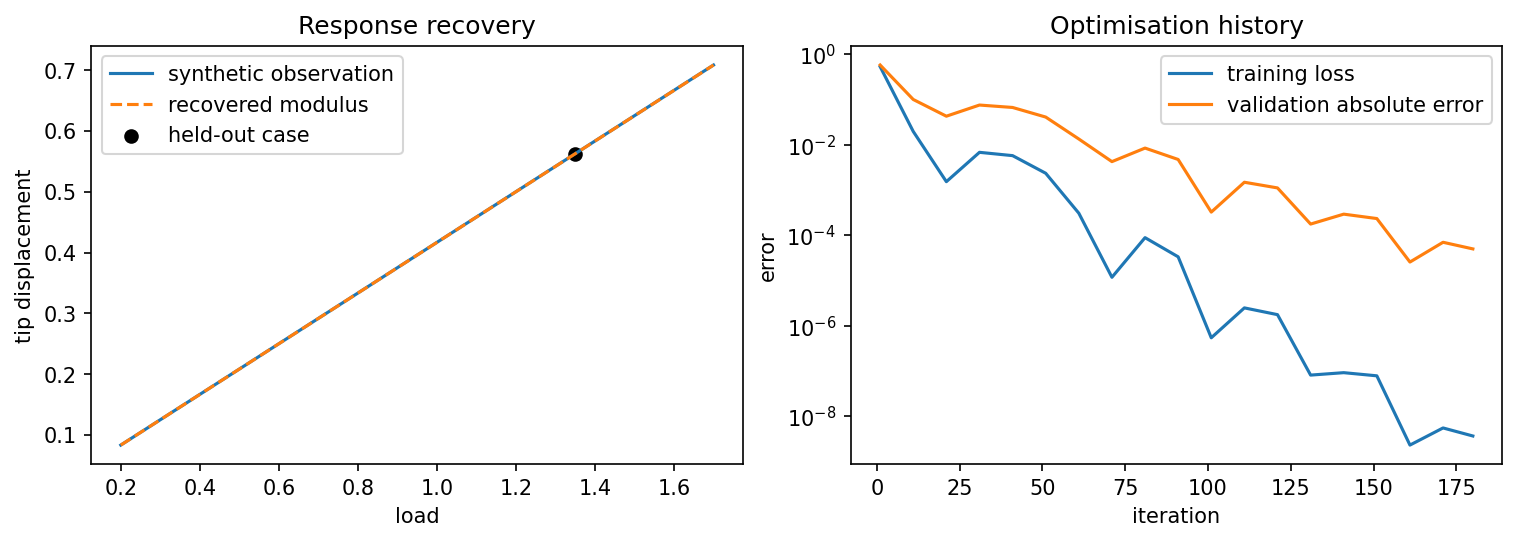

In [4]:
history_array = np.array(history)
response_loads = torch.linspace(0.2, 1.7, 80, dtype=torch.float64)
true_response = np.array([float(tip_displacement(E_true, load)) for load in response_loads])
fit_response = np.array([float(tip_displacement(E_fit, load)) for load in response_loads])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].plot(response_loads, true_response, label="synthetic observation")
axes[0].plot(response_loads, fit_response, "--", label="recovered modulus")
axes[0].scatter([heldout_load], [observed_heldout], color="black", label="held-out case")
axes[0].set(xlabel="load", ylabel="tip displacement", title="Response recovery")
axes[0].legend()
axes[1].semilogy(history_array[:, 0], history_array[:, 2], label="training loss")
axes[1].semilogy(history_array[:, 0], history_array[:, 3], label="validation absolute error")
axes[1].set(xlabel="iteration", ylabel="error", title="Optimisation history")
axes[1].legend()
fig.savefig(assets_dir() / "tiny_inverse_bar.png", dpi=160, bbox_inches="tight")
display_figure(fig, alt="Toy elastic-bar response recovery and optimisation history.")
plt.close(fig)


Compare the recovered modulus and held-out displacement with their
reference values. The analytic bar sensitivity helps explain the
agreement between automatic differentiation and finite differences.
Extending the calculation to fracture introduces a load-dependent
history, irreversibility constraints and sensitivity to the chosen
observations and solver tolerance.


## Exercises

Try each question before opening the hint or worked solution. Keep the original calculation as your reference.

### Exercise 1: Derive the tip sensitivity

The fixed-left, unit-length, unit-area bar has a tip load $F$ and a uniform modulus $E$.

1. Derive $u_{\mathrm{tip}}(E,F)$ and $\mathrm{d}u_{\mathrm{tip}}/\mathrm{d}E$.
2. Evaluate both at $E=1.8$ and $F=1.1$.
3. Compare with the notebook's autograd and centred-FD values.

::::{admonition} Hint 1
:class: dropdown course-hint

For a uniform axial bar, the series assembly gives $u_{\mathrm{tip}}=FL/(EA)$. Here $L=A=1$.
::::

::::{admonition} Worked solution 1
:class: dropdown course-solution

1. With $L=A=1$, the assembled bar has

$$
u_{\mathrm{tip}}=\frac{F}{E}.
$$

Differentiating gives

$$
\frac{\mathrm{d}u_{\mathrm{tip}}}{\mathrm{d}E}=-\frac{F}{E^2}=-\frac{u_{\mathrm{tip}}}{E}.
$$

2. Therefore

$$
u_{\mathrm{tip}}=\frac{1.1}{1.8}=0.6111111111,
\qquad
\frac{\mathrm{d}u_{\mathrm{tip}}}{\mathrm{d}E}=-\frac{1.1}{1.8^2}=-0.3395061728.
$$

3. The autograd value is $-0.33950617283949214$, the centred-FD value is $-0.3395061727862192$, and the analytic value is $-0.3395061728395104$. The negative sign has the expected mechanics interpretation: a stiffer bar displaces less under the same load. The sensitivity follows from the uniform bar's linear elastic constitutive law.
::::

### Exercise 2: Interpret the positive modulus parameterisation

The optimiser holds **log_E** as its trainable parameter and computes $E_{\mathrm{trial}}=\exp(\mathrm{log\_E})$, starting from $E=0.9$. It reports $E_{\mathrm{true}}=2.4$, $E_{\mathrm{fit}}=2.4003023876$, held-out observed displacement $0.5625$, and held-out prediction $0.5624291368$.

1. What values of $E$ can this parameterisation represent?
2. Compare the range of the exponential parameterisation with that of a sigmoid.
3. Compute the absolute held-out displacement error and state one reason the held-out load is useful.

::::{admonition} Hint 2
:class: dropdown course-hint

The exponential maps every real number to a strictly positive number. Compare the observed and predicted held-out displacements directly.
::::

::::{admonition} Worked solution 2
:class: dropdown course-solution

1. Since $\exp(z)>0$ for every real $z$, the parameterisation enforces only $E>0$. It has no finite upper bound. The initial value is obtained because $\exp(\log(0.9))=0.9$.

2. A sigmoid maps a raw parameter to $(0,1)$ before any explicit scaling. The exponential $\exp(\mathrm{log\_E})$ represents every strictly positive modulus, with no finite upper bound.

3. The held-out absolute error is

$$
|0.562499999999992-0.5624291368281488|
=7.0863\times10^{-5}.
$$

The held-out load $1.35$ provides a separate displacement observation beyond the four optimisation loads. Agreement at this load tests the recovered modulus under another loading condition within the same linear elastic model.
::::